# 🐍 Python Level 3 - Advanced course
## Class 3 — Modules and Packages

**Python instructor - Fábio Neves**

---

<div style="display:inline-flex; align-items:center; gap:28px; background:#FFFFFF; color:#1D1D1B; padding:10px 14px; border-radius:8px; margin-bottom:8px;">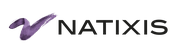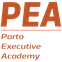</div>

---

---

### 📋 What we'll cover today

| # | Topic |
|---|-------|
| 1 | What is a module? |
| 2 | The standard library — batteries included |
| 3 | Installing more with `pip` |
| 4 | Writing your own module |
| 5 | The three ways to import |
| 6 | Packages — when one file is not enough |
| 7 | 🔗 Putting it all together |

### 🎯 Learning outcomes

By the end of this class you will be able to:

- Use what Python already gives you, instead of writing it again
- Install a library and know what that actually did
- Move your own functions into a module and import them

---

> 📎 **Two extra topics come with slides, not code.** After the exercises your instructor will
> show you **Git and GitHub** and **Streamlit** from a short deck, plus a live demo. There is
> nothing to run and nothing in the exercises about them — they are there so the words mean
> something when you hear them.

---
## 1. What is a module?

A **module** is just a Python file with things in it — functions, classes, values — that
another file can borrow. You have used them since Level 1:

```
import pandas as pd
```

`pandas` is a module (a very large one). `import` finds it and makes its contents available
under the name `pd`.

Why bother, instead of keeping everything in one notebook?

| | One long notebook | Split into modules |
|---|------------------|--------------------|
| Finding a function | scroll | it is in the file named after its job |
| Using it in another notebook | copy and paste | `import` it |
| Fixing a bug | fix every copy | fix it once |
| Two people working | one notebook, one person | a file each |

The rule is the same one from Level 2 Class 1, one level up: **give the job a name.** There it
was a function; here it is a file.

---
## 2. The standard library — batteries included

Python comes with hundreds of modules already installed. Nothing to download; just `import`.
Four you will actually use:

| Module | For | Examples |
|--------|-----|----------|
| `math` | maths beyond `+ - * /` | `math.sqrt()`, `math.pi`, `math.ceil()` |
| `random` | random numbers and choices | `random.randint()`, `random.choice()` |
| `datetime` | dates and times | `date.today()`, `.strftime()` |
| `statistics` | averages and spread | `mean()`, `median()`, `stdev()` |

> 💡 Before writing a function, spend thirty seconds checking whether Python already has it.
> `statistics.median()` is written, tested and faster than the one you were about to write.

> 💡 `random.seed(42)` makes the "random" numbers come out the same every run. That sounds like
> a contradiction, but it is exactly what you want in teaching material and in tests — the
> results are repeatable.

In [1]:
import math
import random

print(math.sqrt(64), math.pi)
print(math.ceil(1.2), math.floor(1.8))     # round up, round down

random.seed(42)                            # same "random" answers every run
print(random.randint(1, 6))
print(random.choice(["Ana", "Bruno", "Clara"]))

8.0 3.141592653589793
2 1
6
Ana


In [2]:
from datetime import date
import statistics

today = date.today()
print(today)                               # today's date, whenever you run it
print(today.strftime("%d/%m/%Y"))          # formatted the way we write it here

launch = date(2026, 3, 14)                 # or build a fixed one: year, month, day
print(launch, "|", launch.strftime("%d %B %Y"), "|", launch.year)

amounts = [1250.00, 480.50, 2400.00, 95.20, 640.00]
print("mean  :", round(statistics.mean(amounts), 2))
print("median:", statistics.median(amounts))
print("stdev :", round(statistics.stdev(amounts), 2))

2026-09-29
29/09/2026
2026-03-14 | 14 March 2026 | 2026
mean  : 973.14
median: 640.0
stdev : 899.59


---
## 3. Installing more with `pip`

Everything else lives on **PyPI**, the Python Package Index — over half a million libraries,
free. `pip` is the tool that fetches one and puts it where `import` can find it:

```
!pip install pandas
```

The `!` at the front means *"this is not Python, it is a command for the computer"*. In Colab
that is how you run an installer.

You have not needed it yet, because Colab arrives with `pandas`, `matplotlib` and `seaborn`
already installed. You will need it for anything less common.

> ⚠️ In Colab, an install lasts only for the **current session**. Close the notebook and it is
> gone, so the `!pip install` line stays in the notebook, at the top, and runs again each time.
> That is normal and expected — not a mistake.

> 💡 `-q` makes it quiet: `!pip install -q some-library` hides pages of output you will not
> read.

In [5]:
# Already installed in Colab, so this just confirms it - and shows the shape of the command
!pip install -q pandas

import pandas as pd
print("pandas version:", pd.__version__)


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
pandas version: 2.2.3


---
## 4. Writing your own module

A module of your own is just **your own code, kept somewhere else**.

In Colab that somewhere else is another **notebook**. Open **`money_tools.ipynb`** — it sits
beside this one — and you will find exactly that: a docstring, a value, two functions. No
report, no printing. Only definitions.

Python can import a notebook, but it needs a small helper called **`import_ipynb`** to do it.
That helper is not built in — which makes it the first real use for `!pip install` from
section 3.

> 📁 **`money_tools.ipynb` must sit next to this notebook.** In Colab, open the **Files** panel
> on the left (the folder icon) and upload it, or keep both notebooks in the same Drive folder.
> If Python says `No module named 'money_tools'`, this is why.

> 💡 The `"""..."""` at the top is the module's **docstring** — the same idea as a function's,
> describing the whole file.

In [7]:
!pip install -q import-ipynb


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip


In [10]:
import import_ipynb                    # lets Python import .ipynb files
import money_tools                     # runs money_tools.ipynb, hands us what it defines

print(money_tools.add_vat(100))
print(money_tools.add_vat(100, rate=6))
print(money_tools.format_eur(1234.5))
print(money_tools.VAT_RATE)            # values come across too, not just functions

123.0
106.0
1,234.50 EUR
23


Two things worth noticing about what just happened.

**The self-test did not print.** `money_tools.ipynb` ends with a small block that prints a few
checks — and none of it appeared. That block is guarded by `if __name__ == "__main__":`, which
means *"only when this notebook is the one being run"*. Importing is not running it directly, so
the block is skipped. That is how a module stays quiet when you import it.

> ⚠️ **Change the module and Python may ignore you.** Once a module is imported, Python
> remembers it and will not read the file again. If an edit seems to have no effect, use
> *Runtime → Restart session*, then run this notebook from the top. This catches everybody once.

---
## 5. The three ways to import

| Written | You then type | Use it when |
|---------|---------------|-------------|
| `import money_tools` | `money_tools.add_vat(100)` | the default — it is obvious where the function came from |
| `from money_tools import add_vat` | `add_vat(100)` | you want one or two things, a lot |
| `import money_tools as mt` | `mt.add_vat(100)` | the name is long, or convention says so |

That third one is why everyone writes `import pandas as pd` — short, and universally
recognised.

### Why not `from money_tools import *`

It exists, it imports everything, and you should not use it:

- You cannot tell where a name came from. Reading `add_vat(100)`, is that yours? pandas'?
- If two modules both define `format_eur`, the second silently wins
- The names you did not want land in your notebook too

Being explicit costs a few characters and saves an afternoon.

In [11]:
# 1 - the whole module
import money_tools
print(money_tools.add_vat(50))

# 2 - just the parts you want
from money_tools import add_vat, format_eur
print(add_vat(50), format_eur(61.5))

# 3 - with a shorter name
import money_tools as mt
print(mt.format_eur(mt.add_vat(50)))

61.5
61.5 61.50 EUR
61.50 EUR


---
## 6. Packages — when one file is not enough

A **package** is a folder of modules. Once a project outgrows a single file, you group the
files into folders:

```
   money_project/
   ├── __init__.py       marks the folder as a package
   ├── tools.py          money_project.tools
   └── reports/
       ├── __init__.py
       └── monthly.py    money_project.reports.monthly
```

The `__init__.py` file is what tells Python *"this folder is a package"*. It is often
completely empty, and that is fine — its presence is the message.

Then `from money_project.tools import add_vat` reaches into the folder with a dot for each
level, exactly like `from datetime import date`.

> 💡 **You do not need to build one today.** This is here so the structure is not a mystery
> when you open somebody's project and find folders of `.py` files with an empty `__init__.py`
> in each. That is all it is.

---
## 7. 🔗 Putting it all together — a reusable toolkit

### The situation

You have written the same three helpers into four different notebooks. This time you put them in
a module once, and import them wherever they are needed — which is exactly how you will build
the project next week.

### What the program must do

1. Read **`payment_tools.ipynb`** — the module beside this notebook, holding a **class** and
   two **functions**
2. Notice it uses the standard library inside itself, rather than writing what already exists
3. Import it here, three different ways
4. Build a small report using only what the module provides — **no rules in this notebook**

### Where each concept appears

| Concept from today | Where it is used |
|--------------------|------------------|
| A module as a notebook | `payment_tools.ipynb` |
| A module's docstring | the top of that notebook |
| `import x` | reaching the class |
| `from x import y` | reaching one function |
| `import x as y` | the short name |
| `statistics` from the standard library | the average, inside the module |
| A class in a module | `Payment`, from Class 2 |
| Functions, f-strings, comprehensions, `for` | Levels 1 and 2 |

In [18]:
# Three imports, three styles - all from the one module notebook
import import_ipynb
import payment_tools
from payment_tools import summarise
import payment_tools as pt

payments = [
    payment_tools.Payment("PAY-001", "Alpha Supplies", 1250.00),
    payment_tools.Payment("PAY-002", "Delta Services", 480.50),
    payment_tools.Payment("PAY-003", "Kestrel Print", 95.20),
    payment_tools.Payment("PAY-004", "Northwind Ltd", 640.00),
]

print("PAYMENTS")
print("-" * 46)
for payment in payments:
    print(payment.describe())

summary = summarise(payments)
print("-" * 46)
print(f"Payments : {summary['count']}")
print(f"Total    : {pt.format_eur(summary['total'])}")
print(f"Average  : {pt.format_eur(summary['average'])}")

PAYMENTS
----------------------------------------------
PAY-001  Alpha Supplies    1,250.00 EUR
PAY-002  Delta Services      480.50 EUR
PAY-003  Kestrel Print        95.20 EUR
PAY-004  Northwind Ltd       640.00 EUR
----------------------------------------------
Payments : 4
Total    : 2,465.70 EUR
Average  : 616.42 EUR


---

### 🎉 That's Level 3 Class 3!

| Concept | Key syntax |
|---------|-----------|
| Use a module | `import math` |
| Standard library | `math`, `random`, `datetime`, `statistics` |
| Repeatable randomness | `random.seed(42)` |
| Install a library | `!pip install -q name` |
| Write your own module | put the definitions in `tools.ipynb`, beside this notebook |
| Import a notebook | `!pip install -q import-ipynb`, then `import import_ipynb` |
| Keep a module quiet | wrap its self-test in `if __name__ == "__main__":` |
| Import the whole thing | `import tools` → `tools.add_vat(100)` |
| Import one part | `from tools import add_vat` → `add_vat(100)` |
| Import with a short name | `import tools as t` → `t.add_vat(100)` |
| Never | `from tools import *` |
| A package | a folder of modules with an `__init__.py` |

> 💡 **The habit worth taking:** when you find yourself pasting the same function into a third
> notebook, that is the moment to make a module. Not before — a helper used once belongs where
> it is used.

> 📎 **Still to come, from the slides:** **Git** keeps the history of a project and lets several
> people work on it; **Streamlit** turns a script into a web page other people can use. Both need
> a local editor such as VS Code — which is exactly where to go after this course.

➡️ Now open the **exercises notebook**.